# Lab 6 Gradient Descent

Name: Anas Kabir

Course: Machine Learning

Performed in: Jupyter Notebook (Anaconda)

Objective:
To apply Gradient Descent for fitting Ohm's Law relation between current and voltage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

R_true = 1000

I_flat = np.linspace(0, 0.01, 50)
V_clean = R_true * I_flat

noise = np.random.normal(0, 0.05, size=I_flat.shape)
V_noisy = V_clean + noise

print("Data generated successfully")

Data generated successfully


In [2]:
I_mean = I_flat.mean()
I_std = I_flat.std()

V_mean = V_noisy.mean()
V_std = V_noisy.std()

I_norm = (I_flat - I_mean) / I_std
V_norm = (V_noisy - V_mean) / V_std

print("Data normalized successfully")

Data normalized successfully


In [3]:
# Initialize parameters

m = 0
b = 0

learning_rate = 0.01
epochs = 1000

n = len(I_norm)

loss_history = []

for i in range(epochs):
    
    # prediction
    V_pred = m * I_norm + b
    
    # error
    error = V_pred - V_norm
    
    # cost function
    loss = (1/n) * np.sum(error**2)
    loss_history.append(loss)
    
    # gradients
    dm = (2/n) * np.sum(error * I_norm)
    db = (2/n) * np.sum(error)
    
    # update values
    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Gradient Descent Completed")

print("Slope:", m)
print("Intercept:", b)

Gradient Descent Completed
Slope: 0.9998804097445332
Intercept: -1.1056711102241865e-16


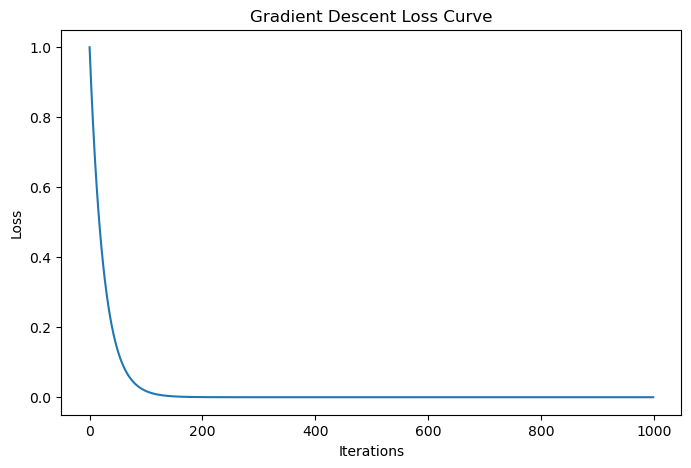

In [4]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("Gradient Descent Loss Curve")

plt.show()

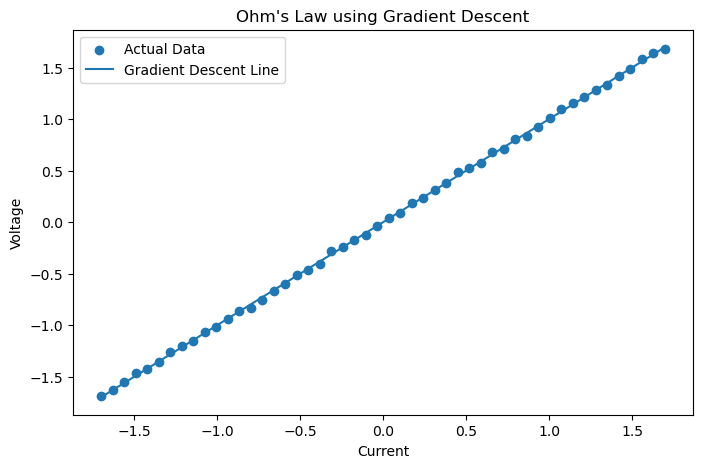

In [5]:
V_prediction = m * I_norm + b

plt.figure(figsize=(8,5))

plt.scatter(I_norm, V_norm, label="Actual Data")

plt.plot(I_norm, V_prediction, label="Gradient Descent Line")

plt.xlabel("Current")
plt.ylabel("Voltage")

plt.title("Ohm's Law using Gradient Descent")

plt.legend()

plt.show()